### This notebook computes "VCA1.Index of farmers recieving training and tehnical assistance" indicator for the 27 basins of IKI Project

Spanish: Índice de productores agropecuarios con capacitación y asistencia técnica

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/9/2026 by Sophia Bakar (sbakar@rti.org)

**Status:** Complete and loaded in SQLite for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, INEI report downloaded from http://censos1.inei.gob.pe/Cenagro/redatam/# 
 
**Assumptions:** Using weighted method to assign values to each COMID.
 
**N/A Handling** COMIDs without productores will result in 0. We should change all 0s to NaN before inserting the results into the database. 

**Calculation Summary** 

**Future work:** 
 
**Notes:** 

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 501 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

# district_area = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/COMID_District_Fractions.csv'
district_area = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\COMID_District_Fractions.csv"

# productores = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/INEI_reporte_VCA1.xlsx'
productores = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad\INEI_reporte_VCA1.xlsx" # make sure file is saved as xlsx before reading in



In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
district_area_within_COMID= pd.read_csv(district_area)
productores= pd.read_excel(productores)

In [6]:
# format the productores dataframe
top_column_name = 'Temas de la capacitación'

#remove empty rows 
productores = productores.dropna(axis=0, how='all')  # Drop rows that are completely NaN

#remove unnamed columns
productores = productores.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')

#Keep only rows with 'Total' or 'AREA' in 'Temas de la capacitación' column
productores = productores[productores[top_column_name].str.contains('Total|AREA', case=False, na=False)]

#extract the district name from the dataframe and make a new column with just the district name
productores['District']= productores['Unnamed: 1'].str.split('Dist. ', expand=True)[1].str.strip()

indices_to_drop = []
# Iterate through the rows to check for AREA rows and their corresponding Total rows
for i in range(len(productores) - 1):  # Stop at the second-to-last row to avoid index errors
    if 'AREA' in str(productores.iloc[i][top_column_name]).upper():  # Check if the current row is an AREA row
        next_row = productores.iloc[i + 1]
        if 'TOTAL' in str(next_row[top_column_name]).upper():  # Check if the next row is a Total row
            # Assign the value from the next row to the "Total_Dist" column of the current row
            productores.at[productores.index[i], 'Total_Dist'] = next_row['Unnamed: 1']
            # Mark the Total row for dropping
            indices_to_drop.append(productores.index[i + 1])
            
# Drop all marked indices at once
productores.drop(index=indices_to_drop, inplace=True)

# Reset the index after dropping rows
productores.reset_index(drop=True, inplace=True)

# Convert Total_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
productores['Total_Dist'] = pd.to_numeric(productores['Total_Dist'], errors='coerce').fillna(0)

#remove all rows from Temas that are NA
productores = productores.dropna(subset=[top_column_name])
#remove all rows from district that are NA
productores = productores.dropna(subset=['District'])

#Create column for District_ID by extracting the number after the # sign in the column Temas de la capacitación
productores['District_ID'] = productores[top_column_name].str.extract(r'(\d+)').astype(int)

# Rename District_ID to IDDIST for consistency with weighted method function
productores = productores.rename(columns={'District_ID': 'IDDIST'})


In [7]:
#WEIGHTED METHOD FUNCTION 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        # Get all districts within this COMID
        districts_in_comid = district_fractions_df[district_fractions_df['COMID'] == comid]
        
        total_proportionate_value = 0
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            # Get the indicator value for this district
            ind_value = value_df[value_df['IDDIST'] == district_id][column_name].values

            if len(ind_value) > 0:
                # Multiply district value by the fraction of area within COMID
                proportionate_value = ind_value[0] * fraction
                total_proportionate_value += proportionate_value
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total_proportionate_value
        })
    
    return pd.DataFrame(results)

In [8]:
# Get unique COMIDs from subbasins_gdf
unique_comids = subbasins_gdf['COMID'].unique()

# Calculate proportionate values using weighted method
proportionate_df = calculate_proportionate_values(
    district_area_within_COMID, 
    productores, 
    'Total_Dist',
    unique_comids
)

# Merge back to subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(
    proportionate_df, 
    on='COMID', 
    how='left'
)

# Rename column and round to nearest whole number
subbasins_gdf = subbasins_gdf.rename(columns={'proportionate_indicator_value': 'Total_Productores'})
subbasins_gdf['Total_Productores'] = subbasins_gdf['Total_Productores'].astype(float).round(0).replace({0: np.nan})

# Display results
print("Sample of proportionate productores values:")
print(subbasins_gdf[['COMID', 'Total_Productores']].head(10))
print(f"\nTotal COMIDs: {len(subbasins_gdf)}")
print(f"COMIDs with productores data (>0): {(subbasins_gdf['Total_Productores'] > 0).sum()}")
print(f"COMIDs without productores data (NaN): {subbasins_gdf['Total_Productores'].isna().sum()}")

Sample of proportionate productores values:
       COMID  Total_Productores
0  311153600               34.0
1  310832400              187.0
2  310825700               32.0
3  310282400               52.0
4  308754600                7.0
5  307736500               12.0
6  307078200                4.0
7  307183500               14.0
8  306538400               51.0
9  306599700              683.0

Total COMIDs: 3655
COMIDs with productores data (>0): 3118
COMIDs without productores data (NaN): 537


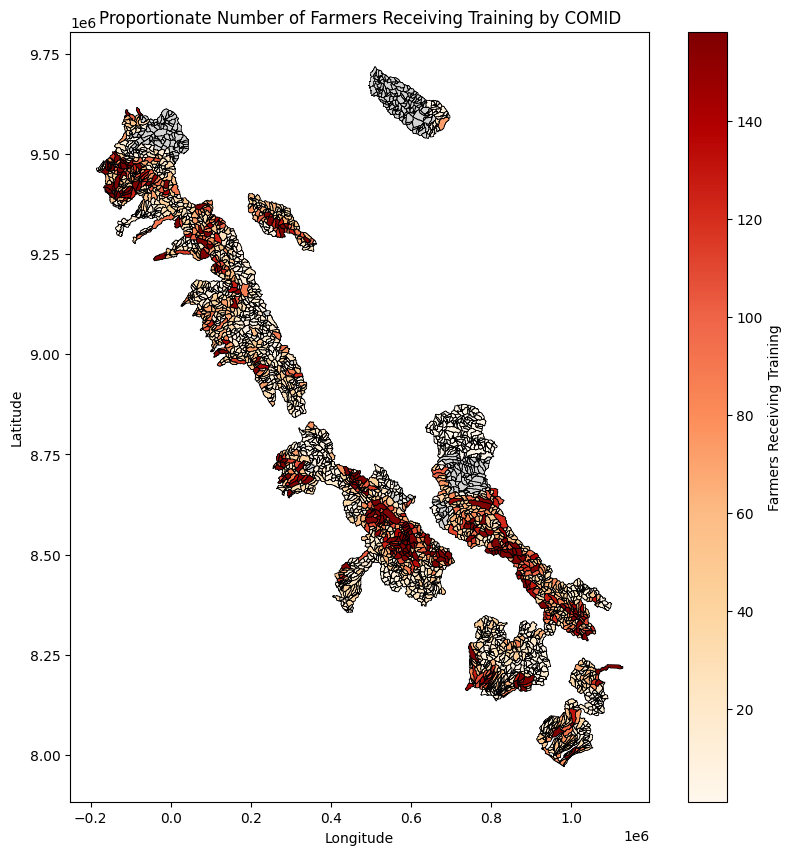

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# Separate NaN and non-NaN values
nan_values = subbasins_gdf[subbasins_gdf['Total_Productores'].isna()]
valid_values = subbasins_gdf[subbasins_gdf['Total_Productores'].notna()]

# Plot NaNs in light grey
nan_values.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='black',
    linewidth=0.5,
    label='No Data'
)

# Scale colorbar using quantiles (robust)
vmin = valid_values['Total_Productores'].quantile(0.05)
vmax = valid_values['Total_Productores'].quantile(0.95)

# Plot valid values with scaled color ramp
valid_values.plot(
    column='Total_Productores',
    ax=ax,
    cmap='OrRd',
    legend=True,
    vmin=vmin,
    vmax=vmax,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': 'Farmers Receiving Training'}
)

plt.title('Proportionate Number of Farmers Receiving Training by COMID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

SQLITE INSERT 

In [10]:
# insert results into the database 
insert_data= subbasins_gdf #COMID 
value_column= 'Total_Productores' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [11]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['Total_Productores']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 501  Min: 0, Max: 2000

=== Values to be inserted (by scenario) ===
   index  Total_Productores
0    min                1.0
1    max             1444.0
2  count             3118.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [12]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()